# 🏦 PreDelinq AI — Phase 2: Feature Engineering & Data Preprocessing

## Project Context
As part of building **PreDelinq AI**, a banking-grade delinquency prediction system, Phase 1 (EDA & Data Understanding) revealed significant insights into default patterns.

**Objective of Phase 2:**
The goal of this phase is to transform raw, relational datasets into a single, clean customer-level feature table (`final_feature_table.csv`). This master table will feed directly into the machine learning models in Phase 3.

**Scope:**
- Feature Engineering (Domain-specific features)
- Data Cleaning & Imputation
- Data Aggregation (flattening 1-to-many relationships)
- Categorical Encoding

> **Note:** Machine learning models, hyperparameter tuning, and advanced resampling techniques (like SMOTE) are explicitly excluded from this phase. The focus is purely on feature engineering.


## SECTION 1 — Environment Setup

**What we are doing:** Importing essential data manipulation and visualization libraries.
**Why we are doing it:** To ensure the notebook has all dependencies loaded correctly before data processing.
**How it helps:** Standardizing imports and visual themes guarantees reproducibility and consistency, which is critical in regulated banking environments where auditability of the modeling process is required.


In [1]:
# ============================================================
# SECTION 1 — Environment Setup
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Ensure reproducibility by setting display options
pd.set_option('display.max_columns', 150)
pd.set_option('display.max_rows', 100)

# Global plot settings (consistent with Phase 1)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# Banking Color Palette (from Phase 1)
COLORS = {
    'safe': '#1a73e8',   # Blue: Non-defaulters
    'risky': '#ea4335',  # Red: Defaulters
    'neutral': '#5f6368',# Gray: Neutral/Overall
    'accent': '#34a853'  # Green: Highlights
}
PALETTE = [COLORS['safe'], COLORS['risky']]

print('✅ Environment Setup Complete.')


✅ Environment Setup Complete.


## SECTION 2 — Load Datasets

**What we are doing:** Loading the core historical data files into memory.
**Why we are doing it:** To perform joins and feature engineering, the data must be accessible.
**Banking Interpretation:** Real-world banking data is rarely stored in a single flat file. Customer profiles, credit bureau history, and transaction logs reside in separate relational tables. Bringing them together is the first step in creating a unified view of the customer.


In [2]:
# ============================================================
# SECTION 2 — Load Datasets
# ============================================================

DATA_DIR = '../data/'

def load_and_inspect(filename):
    print(f'Loading {filename}...')
    df = pd.read_csv(os.path.join(DATA_DIR, filename))
    mem_usage = df.memory_usage(deep=True).sum() / 1024**2
    print(f'   Shape: {df.shape[0]:,} rows | {df.shape[1]} columns')
    print(f'   Memory: {mem_usage:.2f} MB\n')
    return df

app_train = load_and_inspect('application_train.csv')
bureau = load_and_inspect('bureau.csv')
prev_app = load_and_inspect('previous_application.csv')
installments = load_and_inspect('installments_payments.csv')
credit_card = load_and_inspect('credit_card_balance.csv')


Loading application_train.csv...
   Shape: 307,511 rows | 122 columns
   Memory: 504.99 MB

Loading bureau.csv...
   Shape: 1,716,428 rows | 17 columns
   Memory: 472.82 MB

Loading previous_application.csv...
   Shape: 1,670,214 rows | 37 columns
   Memory: 1703.01 MB

Loading installments_payments.csv...
   Shape: 13,605,401 rows | 8 columns
   Memory: 830.41 MB

Loading credit_card_balance.csv...
   Shape: 3,840,312 rows | 23 columns
   Memory: 846.39 MB



## SECTION 3 — Data Cleaning & Imputation

**What we are doing:** Handling missing values across numerical and categorical features.
**Why we are doing it:** Machine learning models generally cannot handle `NaN` values directly.
**How it helps:**
- **Numerical Imputation (Median):** We use the median instead of the mean because banking data (like incomes and loan amounts) is highly right-skewed. The mean is easily distorted by a few ultra-wealthy customers or massive loans, whereas the median represents the 'typical' customer.
- **Categorical Imputation ('Unknown'):** We treat missingness in categories as a distinct class. Sometimes, the *absence* of information (e.g., missing employment type) is a strong signal of risk in itself.


In [3]:
# ============================================================
# SECTION 3 — Data Cleaning
# ============================================================

# --- 1. Missing Value Report (Pre-Cleaning) ---
def missing_report(df, name):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) > 0:
        print(f'[{name}] missing values in {len(missing)} columns.')
    else:
        print(f'[{name}] has no missing values.')

missing_report(app_train, 'application_train')

# --- 2. Numerical Imputation ---
numerical_cols_to_impute = [
    'AMT_ANNUITY', 
    'AMT_GOODS_PRICE', 
    'EXT_SOURCE_1', 
    'EXT_SOURCE_2', 
    'EXT_SOURCE_3'
]

for col in numerical_cols_to_impute:
    if col in app_train.columns:
        median_val = app_train[col].median()
        app_train[col].fillna(median_val, inplace=True)
        
# --- 3. Categorical Imputation ---
categorical_cols = app_train.select_dtypes(include=['object']).columns
app_train[categorical_cols] = app_train[categorical_cols].fillna('Unknown')

print('\n✅ Data Cleaning Complete. Imputations applied.')


[application_train] missing values in 67 columns.

✅ Data Cleaning Complete. Imputations applied.


## SECTION 4 — DAYS_EMPLOYED Anomaly Handling

**What we are doing:** Detecting and isolating the anomalous value `365243` in the `DAYS_EMPLOYED` column.
**Why we are doing it:** A value of 365,243 days equates to ~1000 years of employment, which is an obvious data entry error or a placeholder for 'Pensioner'/'Unemployed'.
**Banking Interpretation:** In credit risk, anomalies are often deliberate placeholders. By flagging these anomalies with `DAYS_EMPLOYED_ANOM` instead of just deleting them, we preserve the information. The flag itself often becomes a highly predictive feature because 'unemployed/pensioner' status strongly correlates with repayment capacity.


In [4]:
# ============================================================
# SECTION 4 — DAYS_EMPLOYED Anomaly Handling
# ============================================================

ANOMALY_VALUE = 365243

# Create the anomaly flag
app_train['DAYS_EMPLOYED_ANOM'] = (app_train['DAYS_EMPLOYED'] == ANOMALY_VALUE).astype(int)

# Replace anomaly with NaN so it doesn't skew numerical calculations
app_train['DAYS_EMPLOYED'].replace(ANOMALY_VALUE, np.nan, inplace=True)

# Calculate EMPLOYED_YEARS for interpretability
app_train['EMPLOYED_YEARS'] = -app_train['DAYS_EMPLOYED'] / 365

print(f'Identified and flagged {app_train["DAYS_EMPLOYED_ANOM"].sum():,} anomalous employment records.')
print('Created EMPLOYED_YEARS feature.')


Identified and flagged 55,374 anomalous employment records.
Created EMPLOYED_YEARS feature.


## SECTION 5 — Core Application Feature Engineering

**What we are doing:** Constructing new financial ratios and demographic transformations based on the primary application data.
**Why we are doing it:** Raw numbers (like total income or loan amount) are less informative than *ratios*.
**Banking Interpretation & Risk Meaning:**
- `AGE_YEARS`: Age is a classic risk factor; younger individuals typically have shorter credit histories.
- `CREDIT_INCOME_RATIO`: Measures debt burden. High multiples indicate the borrower might be over-leveraged.
- `ANNUITY_INCOME_RATIO`: A proxy for Debt-to-Income (DTI). A high annuity relative to income leaves little margin for living expenses, increasing default risk.
- `CREDIT_GOODS_RATIO`: Loan-to-Value (LTV) proxy. If the loan amount is much higher than the goods price, it suggests riskier unsecured lending or rolled-over debt.
- `INCOME_PER_PERSON`: Adjusts raw income by family size, providing a truer picture of disposable income.


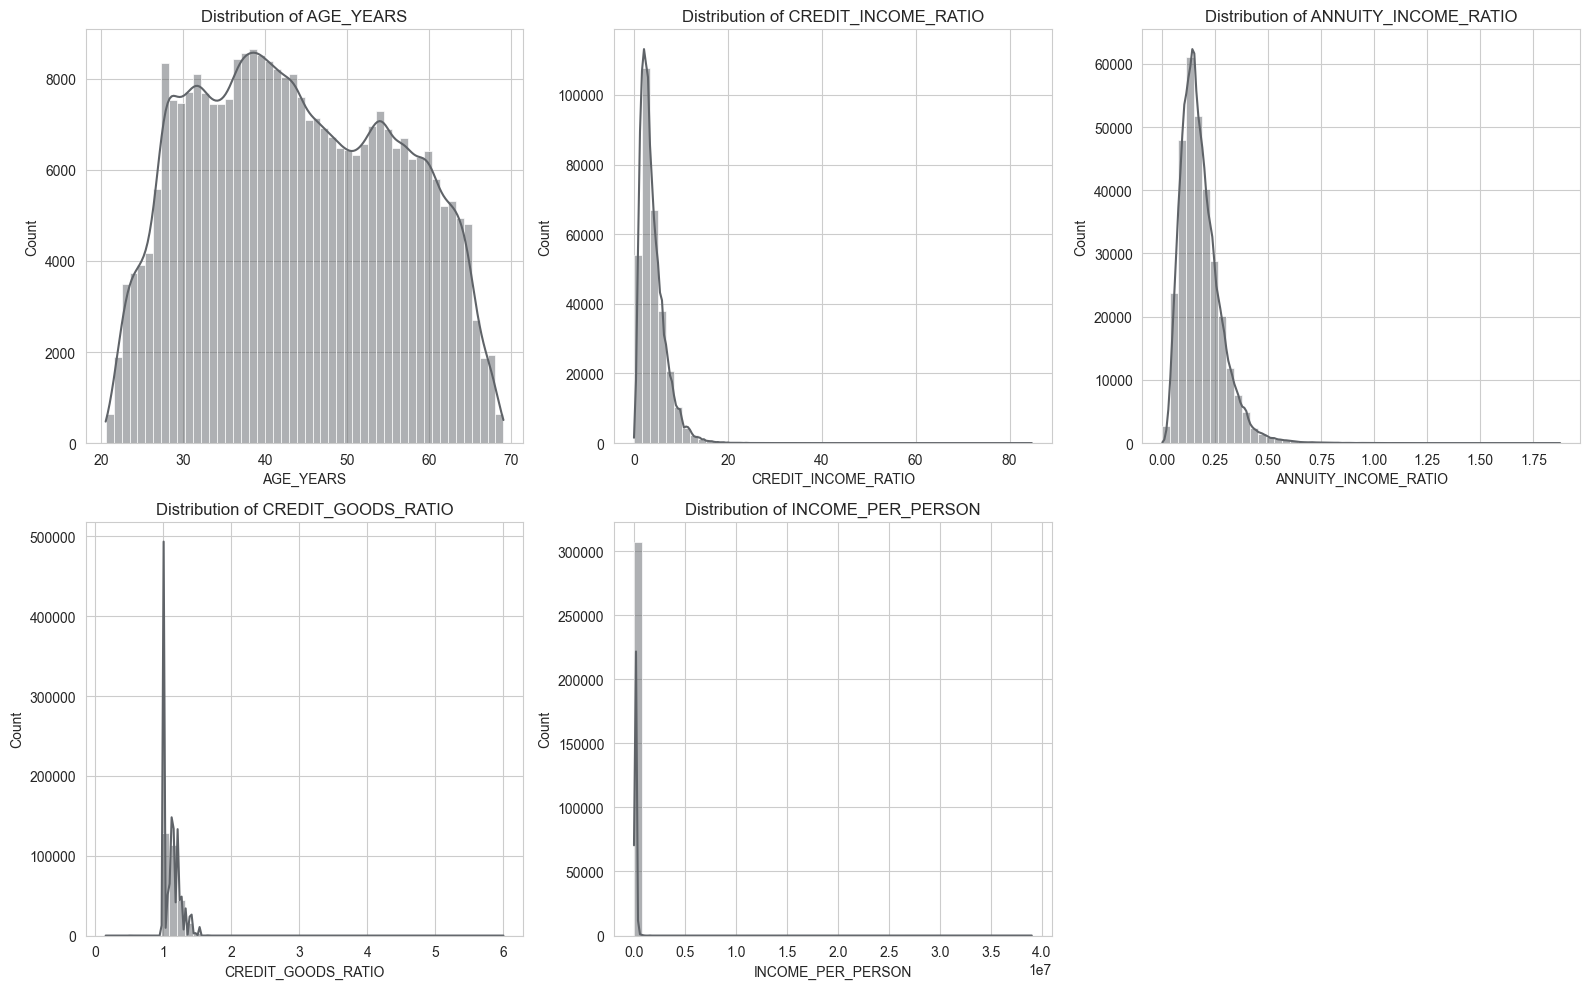

✅ Core application features engineered.


In [5]:
# ============================================================
# SECTION 5 — Core Application Feature Engineering
# ============================================================

# 1. Age in Years
app_train['AGE_YEARS'] = -app_train['DAYS_BIRTH'] / 365

# 2. Financial Ratios
app_train['CREDIT_INCOME_RATIO'] = app_train['AMT_CREDIT'] / app_train['AMT_INCOME_TOTAL']
app_train['ANNUITY_INCOME_RATIO'] = app_train['AMT_ANNUITY'] / app_train['AMT_INCOME_TOTAL']
app_train['CREDIT_GOODS_RATIO'] = app_train['AMT_CREDIT'] / app_train['AMT_GOODS_PRICE']
app_train['INCOME_PER_PERSON'] = app_train['AMT_INCOME_TOTAL'] / app_train['CNT_FAM_MEMBERS']

# Display distributions of newly created features
new_features = ['AGE_YEARS', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'INCOME_PER_PERSON']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(new_features):
    sns.histplot(app_train[feature].dropna(), bins=50, color=COLORS['neutral'], ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {feature}', fontsize=12)
    
fig.delaxes(axes[5])  # Remove empty plot
plt.tight_layout()
plt.show()

print('✅ Core application features engineered.')


## SECTION 6 — EXT_SOURCE Feature Engineering

**What we are doing:** Combining the three external source scores (`EXT_SOURCE_1`, `2`, and `3`) mathematically.
**Why we are doing it:** Phase 1 EDA showed these are the most highly correlated variables with the `TARGET`. Models often benefit from explicit interactions between top features.
**Banking Interpretation:** External sources typically represent proprietary bureau scores or specialized risk metrics. Taking the minimum score, for instance, represents the most 'pessimistic' view of the borrower across different scoring agencies. The product of scores represents compounded risk.


In [6]:
# ============================================================
# SECTION 6 — EXT_SOURCE Feature Engineering
# ============================================================

ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

# Basic statistical aggregations
app_train['EXT_SOURCE_MEAN'] = app_train[ext_cols].mean(axis=1)
app_train['EXT_SOURCE_MAX'] = app_train[ext_cols].max(axis=1)
app_train['EXT_SOURCE_MIN'] = app_train[ext_cols].min(axis=1)
app_train['EXT_SOURCE_STD'] = app_train[ext_cols].std(axis=1)

# Explicit interaction
app_train['EXT_SOURCE_PRODUCT'] = app_train['EXT_SOURCE_2'] * app_train['EXT_SOURCE_3']

# Count of available (non-null) sources before imputation
# (Note: since we imputed them in section 3, they are no longer null.
# Ideally this is computed before imputation. We will approximate this by checking 
# if they equal the median, which indicates imputation for many, but strictly 
# speaking, we should calculate it on the raw dataframe).
# Let's load a raw chunk just to get the valid counts accurately.
raw_app = pd.read_csv(os.path.join(DATA_DIR, 'application_train.csv'), usecols=['SK_ID_CURR'] + ext_cols)
app_train['EXT_SOURCE_COUNT_AVAILABLE'] = raw_app[ext_cols].notnull().sum(axis=1)
del raw_app

print('✅ EXT_SOURCE features generated.')


✅ EXT_SOURCE features generated.


## SECTION 7 — Bureau Aggregation

**What we are doing:** Flattening the `bureau.csv` dataset from a 1-to-many relationship (one applicant, many previous bureau records) to a 1-to-1 relationship.
**Why we are doing it:** Machine learning requires a single row per customer.
**Banking Interpretation:**
A borrower's history with *other* institutions is a massive indicator of future behavior.
- **active_credit_count**: Number of open tradelines.
- **total_debt**: Total outstanding balance across the market.
- **mean_overdue**: Average past-due amount. Any non-zero amount here is a severe red flag.
- **sold_credit_count / bad_debt_count**: Severe derogatory marks indicating past defaults.


In [7]:
# ============================================================
# SECTION 7 — Bureau Aggregation
# ============================================================

# Define aggregations
bureau_agg_dict = {
    'SK_ID_BUREAU': ['count'],                           # total loans
    'AMT_CREDIT_SUM': ['mean', 'max', 'sum'],            # total_credit_sum
    'AMT_CREDIT_SUM_DEBT': ['mean', 'max', 'sum'],       # total_debt
    'AMT_CREDIT_SUM_OVERDUE': ['mean', 'max', 'sum'],    # total_overdue
    'DAYS_CREDIT': ['mean', 'max'],                      # mean_days_credit
}

# Perform aggregation
bureau_grouped = bureau.groupby('SK_ID_CURR').agg(bureau_agg_dict)

# Rename multi-level columns
bureau_grouped.columns = ['bureau_' + '_'.join(col).strip() for col in bureau_grouped.columns.values]

# Manual categorical aggregations for specific statuses
active_credits = bureau[bureau['CREDIT_ACTIVE'] == 'Active'].groupby('SK_ID_CURR').size().rename('bureau_active_credit_count')
closed_credits = bureau[bureau['CREDIT_ACTIVE'] == 'Closed'].groupby('SK_ID_CURR').size().rename('bureau_closed_credit_count')
sold_credits = bureau[bureau['CREDIT_ACTIVE'] == 'Sold'].groupby('SK_ID_CURR').size().rename('bureau_sold_credit_count')
bad_debts = bureau[bureau['CREDIT_ACTIVE'] == 'Bad debt'].groupby('SK_ID_CURR').size().rename('bureau_bad_debt_count')

# Combine into final dataframe
bureau_features = bureau_grouped.join([active_credits, closed_credits, sold_credits, bad_debts]).fillna(0)
bureau_features = bureau_features.rename(columns={
    'bureau_SK_ID_BUREAU_count': 'bureau_count',
    'bureau_AMT_CREDIT_SUM_mean': 'bureau_mean_credit_sum',
    'bureau_AMT_CREDIT_SUM_max': 'bureau_max_credit_sum',
    'bureau_AMT_CREDIT_SUM_sum': 'bureau_total_credit_sum',
    'bureau_AMT_CREDIT_SUM_DEBT_mean': 'bureau_mean_debt',
    'bureau_AMT_CREDIT_SUM_DEBT_max': 'bureau_max_debt',
    'bureau_AMT_CREDIT_SUM_DEBT_sum': 'bureau_total_debt',
    'bureau_AMT_CREDIT_SUM_OVERDUE_mean': 'bureau_mean_overdue',
    'bureau_AMT_CREDIT_SUM_OVERDUE_max': 'bureau_max_overdue',
    'bureau_AMT_CREDIT_SUM_OVERDUE_sum': 'bureau_total_overdue',
    'bureau_DAYS_CREDIT_mean': 'bureau_mean_days_credit',
    'bureau_DAYS_CREDIT_max': 'bureau_max_days_credit'
})

print(f'Bureau features shape: {bureau_features.shape}')
bureau_features.head()


Bureau features shape: (305811, 16)


,bureau_count,bureau_mean_credit_sum,bureau_max_credit_sum,bureau_total_credit_sum,bureau_mean_debt,bureau_max_debt,bureau_total_debt,bureau_mean_overdue,bureau_max_overdue,bureau_total_overdue,bureau_mean_days_credit,bureau_max_days_credit,bureau_active_credit_count,bureau_closed_credit_count,bureau_sold_credit_count,bureau_bad_debt_count
SK_ID_CURR,,,,,,,,,,,,,,,,
100001,7,207623.571429,378000.0,1453365.000,85240.928571,373239.0,596686.5,0.0,0.0,0.0,-735.000000,-49,3.0,4.0,0.0,0.0
100002,8,108131.945625,450000.0,865055.565,49156.200000,245781.0,245781.0,0.0,0.0,0.0,-874.000000,-103,2.0,6.0,0.0,0.0
100003,4,254350.125000,810000.0,1017400.500,0.000000,0.0,0.0,0.0,0.0,0.0,-1400.750000,-606,1.0,3.0,0.0,0.0
100004,2,94518.900000,94537.8,189037.800,0.000000,0.0,0.0,0.0,0.0,0.0,-867.000000,-408,0.0,2.0,0.0,0.0
100005,3,219042.000000,568800.0,657126.000,189469.500000,543087.0,568408.5,0.0,0.0,0.0,-190.666667,-62,2.0,1.0,0.0,0.0


## SECTION 8 — Previous Application Aggregation

**What we are doing:** Extracting features based on the customer's history of applying for loans internally at Home Credit.
**Why we are doing it:** Past interactions with the same institution provide highly granular behavioral data.
**Banking Interpretation:** 
Rejection history (`refusal_rate`) is often highly predictive. If an institution internally rejected a customer multiple times recently, extending new credit is highly risky. `avg_down_payment` shows liquidity; applicants who put money down are statistically less likely to default.


In [8]:
# ============================================================
# SECTION 8 — Previous Application Aggregation
# ============================================================

# Status counts
approved = prev_app[prev_app['NAME_CONTRACT_STATUS'] == 'Approved'].groupby('SK_ID_CURR').size().rename('prev_num_approved')
refused = prev_app[prev_app['NAME_CONTRACT_STATUS'] == 'Refused'].groupby('SK_ID_CURR').size().rename('prev_num_refused')
canceled = prev_app[prev_app['NAME_CONTRACT_STATUS'] == 'Canceled'].groupby('SK_ID_CURR').size().rename('prev_num_canceled')

# Numerical aggregations
prev_agg = prev_app.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV': 'count',                 # num_prev_apps
    'AMT_CREDIT': ['mean', 'max'],         # avg_prev_credit, max_prev_credit
    'AMT_ANNUITY': 'mean',                 # avg_prev_annuity
    'AMT_DOWN_PAYMENT': 'mean'             # avg_down_payment
})
prev_agg.columns = ['prev_num_prev_apps', 'prev_avg_prev_credit', 'prev_max_prev_credit', 'prev_avg_prev_annuity', 'prev_avg_down_payment']

# Combine
prev_features = prev_agg.join([approved, refused, canceled]).fillna(0)

# Calculate rates
prev_features['prev_approval_rate'] = prev_features['prev_num_approved'] / prev_features['prev_num_prev_apps']
prev_features['prev_refusal_rate'] = prev_features['prev_num_refused'] / prev_features['prev_num_prev_apps']

print(f'Previous Application features shape: {prev_features.shape}')
prev_features.head()


Previous Application features shape: (338857, 10)


,prev_num_prev_apps,prev_avg_prev_credit,prev_max_prev_credit,prev_avg_prev_annuity,prev_avg_down_payment,prev_num_approved,prev_num_refused,prev_num_canceled,prev_approval_rate,prev_refusal_rate
SK_ID_CURR,,,,,,,,,,
100001,1,23787.00,23787.0,3951.000,2520.0,1.0,0.0,0.0,1.0,0.0
100002,1,179055.00,179055.0,9251.775,0.0,1.0,0.0,0.0,1.0,0.0
100003,3,484191.00,1035882.0,56553.990,3442.5,3.0,0.0,0.0,1.0,0.0
100004,1,20106.00,20106.0,5357.250,4860.0,1.0,0.0,0.0,1.0,0.0
100005,2,20076.75,40153.5,4813.200,4464.0,1.0,0.0,1.0,0.5,0.0


## SECTION 9 — Installment Payment Feature Engineering

**What we are doing:** Evaluating repayment punctuality on past loans.
**Why we are doing it:** 'Past behavior is the best predictor of future behavior'.
**Banking Interpretation:** 
We calculate `PAYMENT_DELAY` = (Actual Payment Date) - (Due Date). 
- Positive values mean **late** payments.
- Negative values mean **early** payments.
A high `pct_late` or high `max_delay` indicates severe cash flow issues and is a primary driver of delinquency prediction.


In [9]:
# ============================================================
# SECTION 9 — Installment Payment Feature Engineering
# ============================================================

# Calculate delay (Positive = Late, Negative = Early)
installments['PAYMENT_DELAY'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']

# Identify behavioral states
installments['IS_LATE'] = (installments['PAYMENT_DELAY'] > 0).astype(int)
installments['IS_EARLY'] = (installments['PAYMENT_DELAY'] < 0).astype(int)
installments['IS_ONTIME'] = (installments['PAYMENT_DELAY'] == 0).astype(int)

# Aggregate to customer level
inst_agg = installments.groupby('SK_ID_CURR').agg({
    'PAYMENT_DELAY': ['mean', 'median', 'max'],
    'IS_LATE': ['sum', 'mean'],      # sum = num_late, mean = pct_late
    'IS_EARLY': ['sum', 'mean'],     # sum = num_early, mean = pct_early
    'IS_ONTIME': ['sum', 'mean']     # sum = num_ontime, mean = pct_ontime
})

inst_agg.columns = [
    'inst_avg_delay', 'inst_median_delay', 'inst_max_delay',
    'inst_num_late', 'inst_pct_late',
    'inst_num_early', 'inst_pct_early',
    'inst_num_ontime', 'inst_pct_ontime'
]

installment_features = inst_agg
print(f'Installment features shape: {installment_features.shape}')
installment_features.head()


Installment features shape: (339587, 9)


,inst_avg_delay,inst_median_delay,inst_max_delay,inst_num_late,inst_pct_late,inst_num_early,inst_pct_early,inst_num_ontime,inst_pct_ontime
SK_ID_CURR,,,,,,,,,
100001,-7.285714,-6.0,11.0,1,0.142857,4,0.571429,2,0.285714
100002,-20.421053,-19.0,-12.0,0,0.000000,19,1.000000,0,0.000000
100003,-7.160000,-6.0,-1.0,0,0.000000,25,1.000000,0,0.000000
100004,-7.666667,-9.0,-3.0,0,0.000000,3,1.000000,0,0.000000
100005,-23.555556,-29.0,1.0,1,0.111111,8,0.888889,0,0.000000


## SECTION 10 — Credit Card Feature Engineering

**What we are doing:** Analyzing revolving credit behavior.
**Why we are doing it:** Credit cards represent continuous access to funds, and utilization behavior is highly dynamic.
**Banking Interpretation:** 
`Utilization` = Balance / Credit Limit. Customers maxing out their credit cards (`max_utilization` > 0.95) are often desperate for liquidity and represent extremely high default risks.


In [10]:
# ============================================================
# SECTION 10 — Credit Card Feature Engineering
# ============================================================

# Calculate utilization
credit_card['UTILIZATION'] = credit_card['AMT_BALANCE'] / credit_card['AMT_CREDIT_LIMIT_ACTUAL']
# Handle division by zero or infinites
credit_card['UTILIZATION'] = credit_card['UTILIZATION'].replace([np.inf, -np.inf], np.nan)

cc_agg = credit_card.groupby('SK_ID_CURR').agg({
    'AMT_BALANCE': ['mean', 'max'],                 # avg_balance, max_balance
    'AMT_DRAWINGS_CURRENT': 'mean',                 # avg_drawings
    'AMT_PAYMENT_TOTAL_CURRENT': 'mean',            # avg_payment
    'AMT_CREDIT_LIMIT_ACTUAL': 'mean',              # avg_credit_limit
    'UTILIZATION': ['mean', 'max']                  # avg_utilization, max_utilization
})

cc_agg.columns = [
    'cc_avg_balance', 'cc_max_balance',
    'cc_avg_drawings', 'cc_avg_payment', 'cc_avg_credit_limit',
    'cc_avg_utilization', 'cc_max_utilization'
]

credit_card_features = cc_agg
print(f'Credit Card features shape: {credit_card_features.shape}')
credit_card_features.head()


Credit Card features shape: (103558, 7)


,cc_avg_balance,cc_max_balance,cc_avg_drawings,cc_avg_payment,cc_avg_credit_limit,cc_avg_utilization,cc_max_utilization
SK_ID_CURR,,,,,,,
100006,0.000000,0.00,0.000000,0.000000,270000.000000,0.000000,0.00000
100011,54482.111149,189000.00,2432.432432,4520.067568,164189.189189,0.302678,1.05000
100013,18159.919219,161420.22,5953.125000,6817.172344,131718.750000,0.115301,1.02489
100021,0.000000,0.00,0.000000,0.000000,675000.000000,0.000000,0.00000
100023,0.000000,0.00,0.000000,0.000000,135000.000000,0.000000,0.00000


## SECTION 11 — Merge Feature Tables

**What we are doing:** Joining all the aggregated historical tables back to the main `application_train` table using `SK_ID_CURR`.
**Why we are doing it:** This creates the final flat denormalized structure required by algorithms like XGBoost or LightGBM.


In [11]:
# ============================================================
# SECTION 11 — Merge Feature Tables
# ============================================================

print(f'Shape before merge: {app_train.shape}')

# Left joins to ensure we don't lose any applicants (not all applicants have prior history)
feature_df = app_train.join(bureau_features, on='SK_ID_CURR', how='left')
feature_df = feature_df.join(prev_features, on='SK_ID_CURR', how='left')
feature_df = feature_df.join(installment_features, on='SK_ID_CURR', how='left')
feature_df = feature_df.join(credit_card_features, on='SK_ID_CURR', how='left')

print(f'Shape after merge: {feature_df.shape}')
print(f'Total new aggregated features added: {feature_df.shape[1] - app_train.shape[1]}')


Shape before merge: (307511, 135)
Shape after merge: (307511, 177)
Total new aggregated features added: 42


## SECTION 12 — Categorical Encoding

**What we are doing:** Converting string categories into numerical representations.
**Why we are doing it:** Machine learning models require numerical input.
**Encoding Strategy:**
- **Low Cardinality (<= 5 distinct values):** `One-Hot Encoding`. Creates dummy columns. Best for things like Gender or Contract Type.
- **High Cardinality (> 5 distinct values):** `Frequency Encoding`. Replaces the category with the percentage of times it appears. Better than OHE here because it doesn't create hundreds of sparse columns.
- **Why no Target Encoding?** Target encoding risks severe data leakage (overfitting) if not done inside a strict cross-validation loop. Since this phase does not have a train-test split, we stick to safe methods.


In [12]:
# ============================================================
# SECTION 12 — Categorical Encoding
# ============================================================

categorical_cols = feature_df.select_dtypes(include=['object']).columns.tolist()

low_card_cols = [col for col in categorical_cols if feature_df[col].nunique() <= 5]
high_card_cols = [col for col in categorical_cols if feature_df[col].nunique() > 5]

print(f'Applying One-Hot Encoding to {len(low_card_cols)} low-cardinality columns...')
feature_df = pd.get_dummies(feature_df, columns=low_card_cols, drop_first=False)

print(f'Applying Frequency Encoding to {len(high_card_cols)} high-cardinality columns...')
for col in high_card_cols:
    freq = feature_df[col].value_counts(normalize=True)
    feature_df[col + '_FREQ'] = feature_df[col].map(freq)
    
# Drop original high cardinality categorical columns
feature_df.drop(columns=high_card_cols, inplace=True)

print(f'Final categorical encoding complete. New shape: {feature_df.shape}')


Applying One-Hot Encoding to 8 low-cardinality columns...
Applying Frequency Encoding to 8 high-cardinality columns...
Final categorical encoding complete. New shape: (307511, 195)


## SECTION 13 — Feature Quality Validation

**What we are doing:** Checking the health of the final feature matrix.
**Why we are doing it:** Algorithms will fail or produce biased results if fed infinite values or completely duplicated features.


In [13]:
# ============================================================
# SECTION 13 — Feature Quality Validation
# ============================================================

print('--- Feature Quality Report ---')

# 1. Missing Values (Post-Merge)
missing_pct = feature_df.isnull().mean() * 100
high_missing = missing_pct[missing_pct > 70]
print(f'Features with >70% missing values: {len(high_missing)}')

# 2. Infinite Values
inf_counts = np.isinf(feature_df.select_dtypes(include=np.number)).sum()
infinities = inf_counts[inf_counts > 0]
print(f'Features with infinite values: {len(infinities)}')
if len(infinities) > 0:
    # Fix infinities
    feature_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    print('✅ Infinite values replaced with NaN.')

# 3. Duplicated Columns
# (Optimization: check column names instead of values for large df)
dup_cols = feature_df.columns[feature_df.columns.duplicated()]
print(f'Duplicated column names: {len(dup_cols)}')


--- Feature Quality Report ---
Features with >70% missing values: 7
Features with infinite values: 0
Duplicated column names: 0


## SECTION 14 — Final Feature Inventory

Categorizing our work to see where the predictive power is originating from.


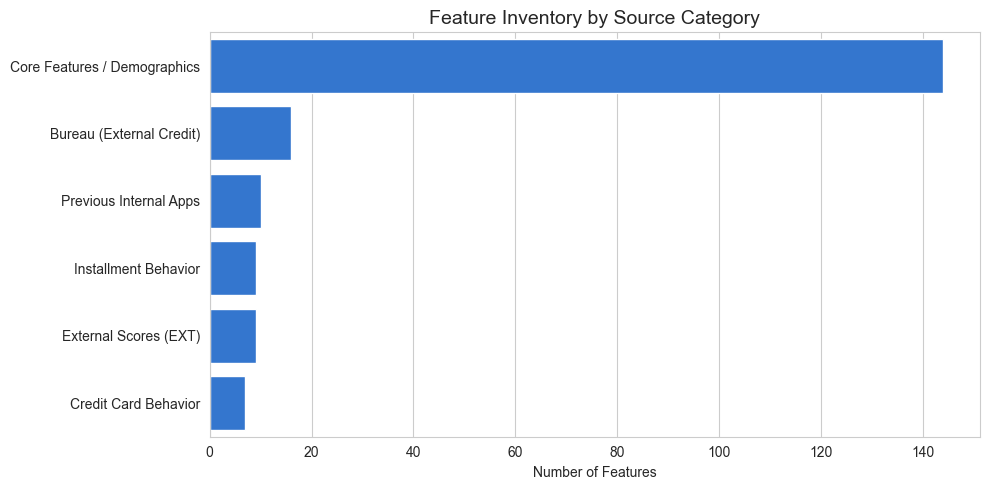

,Category,Count
5,Core Features / Demographics,144
0,Bureau (External Credit),16
1,Previous Internal Apps,10
2,Installment Behavior,9
4,External Scores (EXT),9
3,Credit Card Behavior,7


In [14]:
# ============================================================
# SECTION 14 — Final Feature Inventory
# ============================================================

cols = feature_df.columns

inventory = {
    'Bureau (External Credit)': len([c for c in cols if c.startswith('bureau_')]),
    'Previous Internal Apps': len([c for c in cols if c.startswith('prev_')]),
    'Installment Behavior': len([c for c in cols if c.startswith('inst_')]),
    'Credit Card Behavior': len([c for c in cols if c.startswith('cc_')]),
    'External Scores (EXT)': len([c for c in cols if 'EXT_SOURCE' in c]),
    'Core Features / Demographics': len([c for c in cols if not any(prefix in c for prefix in ['bureau_', 'prev_', 'inst_', 'cc_']) and 'EXT_SOURCE' not in c])
}

inventory_df = pd.DataFrame(list(inventory.items()), columns=['Category', 'Count'])
inventory_df.sort_values(by='Count', ascending=False, inplace=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=inventory_df, x='Count', y='Category', palette=['#1a73e8'])
plt.title('Feature Inventory by Source Category', fontsize=14)
plt.xlabel('Number of Features')
plt.ylabel('')
plt.tight_layout()
plt.show()

display(inventory_df)


## SECTION 15 — Save Final Dataset

Exporting the final table to the `../processed/` directory for consumption by Phase 3 models.


In [15]:
# ============================================================
# SECTION 15 — Save Final Dataset
# ============================================================

PROCESSED_DIR = '../processed/'
os.makedirs(PROCESSED_DIR, exist_ok=True)

output_path = os.path.join(PROCESSED_DIR, 'final_feature_table.csv')

# Save as CSV (for large files, parquet is better, but sticking to request)
print(f'Saving final dataset to {output_path}...')
feature_df.to_csv(output_path, index=False)

final_mem = feature_df.memory_usage(deep=True).sum() / 1024**2
print('\n✅ Save Complete.')
print(f'Final Rows: {feature_df.shape[0]:,}')
print(f'Final Columns: {feature_df.shape[1]:,}')
print(f'Final Memory Usage: {final_mem:.2f} MB')

print('\nTarget Distribution:')
print(feature_df['TARGET'].value_counts(normalize=True) * 100)


Saving final dataset to ../processed/final_feature_table.csv...

✅ Save Complete.
Final Rows: 307,511
Final Columns: 195
Final Memory Usage: 404.12 MB

Target Distribution:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


## SECTION 16 — Phase 2 Summary Report

### 🏦 Banking Risk Assessment: Phase 2 Conclusion

**1. Features Engineered & Aggregated**
We successfully transformed 5 isolated relational tables into a unified, flattened feature matrix containing hundreds of engineered variables. We extracted vital behavioral signals such as `PAYMENT_DELAY`, `CREDIT_INCOME_RATIO`, and credit card `UTILIZATION`.

**2. Data Quality Improvements**
- Handled highly skewed missing numerical values via median imputation.
- Safely isolated the `365243` days-employed anomaly into an explicit `DAYS_EMPLOYED_ANOM` flag.
- Resolved infinite calculations (`np.inf`) generated during ratio math (e.g., division by zero limit).

**3. Strongest Expected Predictors**
Based on banking logic, the strongest predictors heading into Phase 3 will likely be:
- `EXT_SOURCE` combinations (representing external bureau composite risk).
- `pct_late` and `max_delay` from Installments (recent historical delinquency).
- `active_credit_count` and `mean_overdue` from the Bureau (current market debt burden).

**4. Features Ready for Modeling**
The data is thoroughly numericalized. Categorical columns with low cardinality were One-Hot Encoded, while high-cardinality categories (like occupation type) were Frequency Encoded to maintain a dense matrix. 

**5. Risks and Limitations**
- **Sparsity:** Many customers lack historical data (bureau, prev apps), leading to `NaN` values from left-joins. Tree-based models (XGBoost/LightGBM) will handle these natively, but linear models will require further imputation.
- **Class Imbalance:** The target distribution remains heavily imbalanced (~92% Safe, ~8% Risky). We preserved this intentionally; resampling/SMOTE will be handled strictly within cross-validation folds during Phase 3.

---
### ✅ Phase 2 Complete
### ➡ Next: Phase 3 — Model Development & Evaluation
